In [1]:
import numpy as np
import pyarrow.parquet as pq
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PARQUET_PATH = Path("/Users/mainframe/Workspace/Graduate/notebooks/plant_gotchi_train.parquet")

df = pq.read_table(source=PARQUET_PATH, use_threads=True).to_pandas()

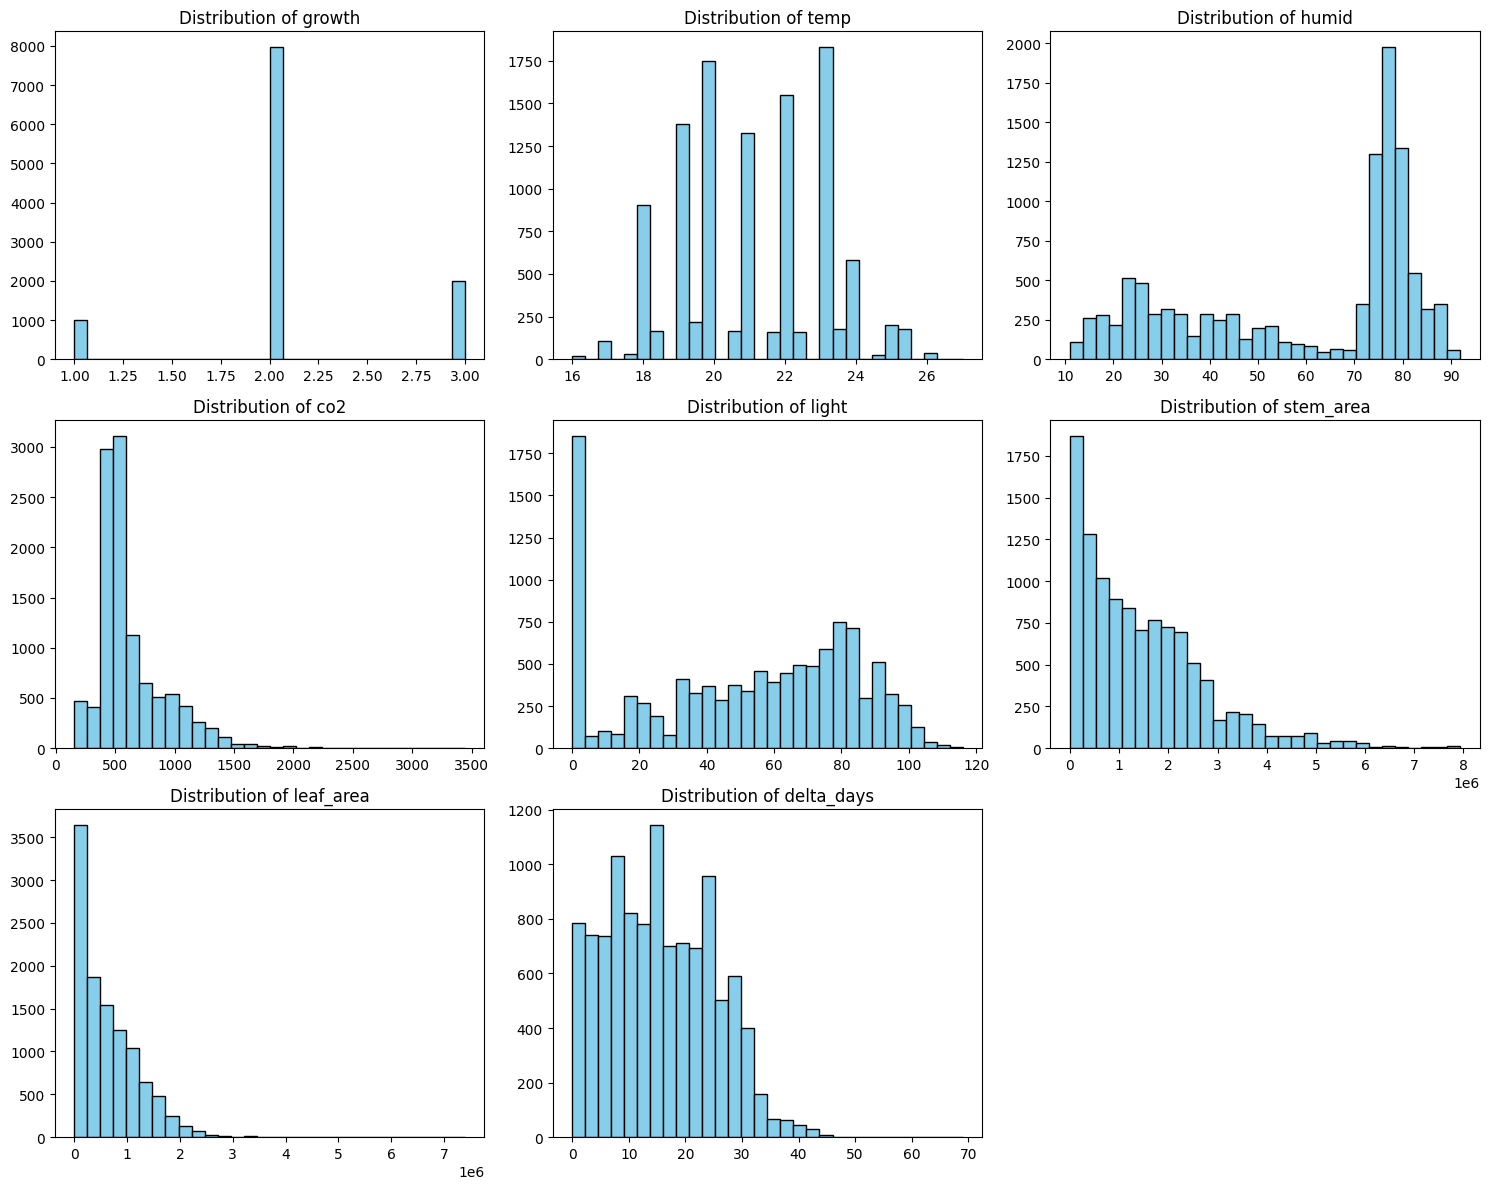

Growth Stage Counts:
growth
1     999
2    7974
3    1996
Name: count, dtype: int64


In [3]:
# List the variables we want to see
variables = ['growth', 'temp', 'humid', 'co2', 'light', 'stem_area', 'leaf_area', 'delta_days']

# Create a grid of histograms
# We use a 3x3 grid to fit all 7 variables comfortably
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Plotting the histogram
    axes[i].hist(df[var].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {var}')
    #axes[i].set_grid(axis='y', alpha=0.3)

# Hide the two empty subplots at the end of the 3x3 grid
for j in range(len(variables), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Just the "Value itself" for growth stages (as requested)
print("Growth Stage Counts:")
print(df['growth'].value_counts().sort_index())

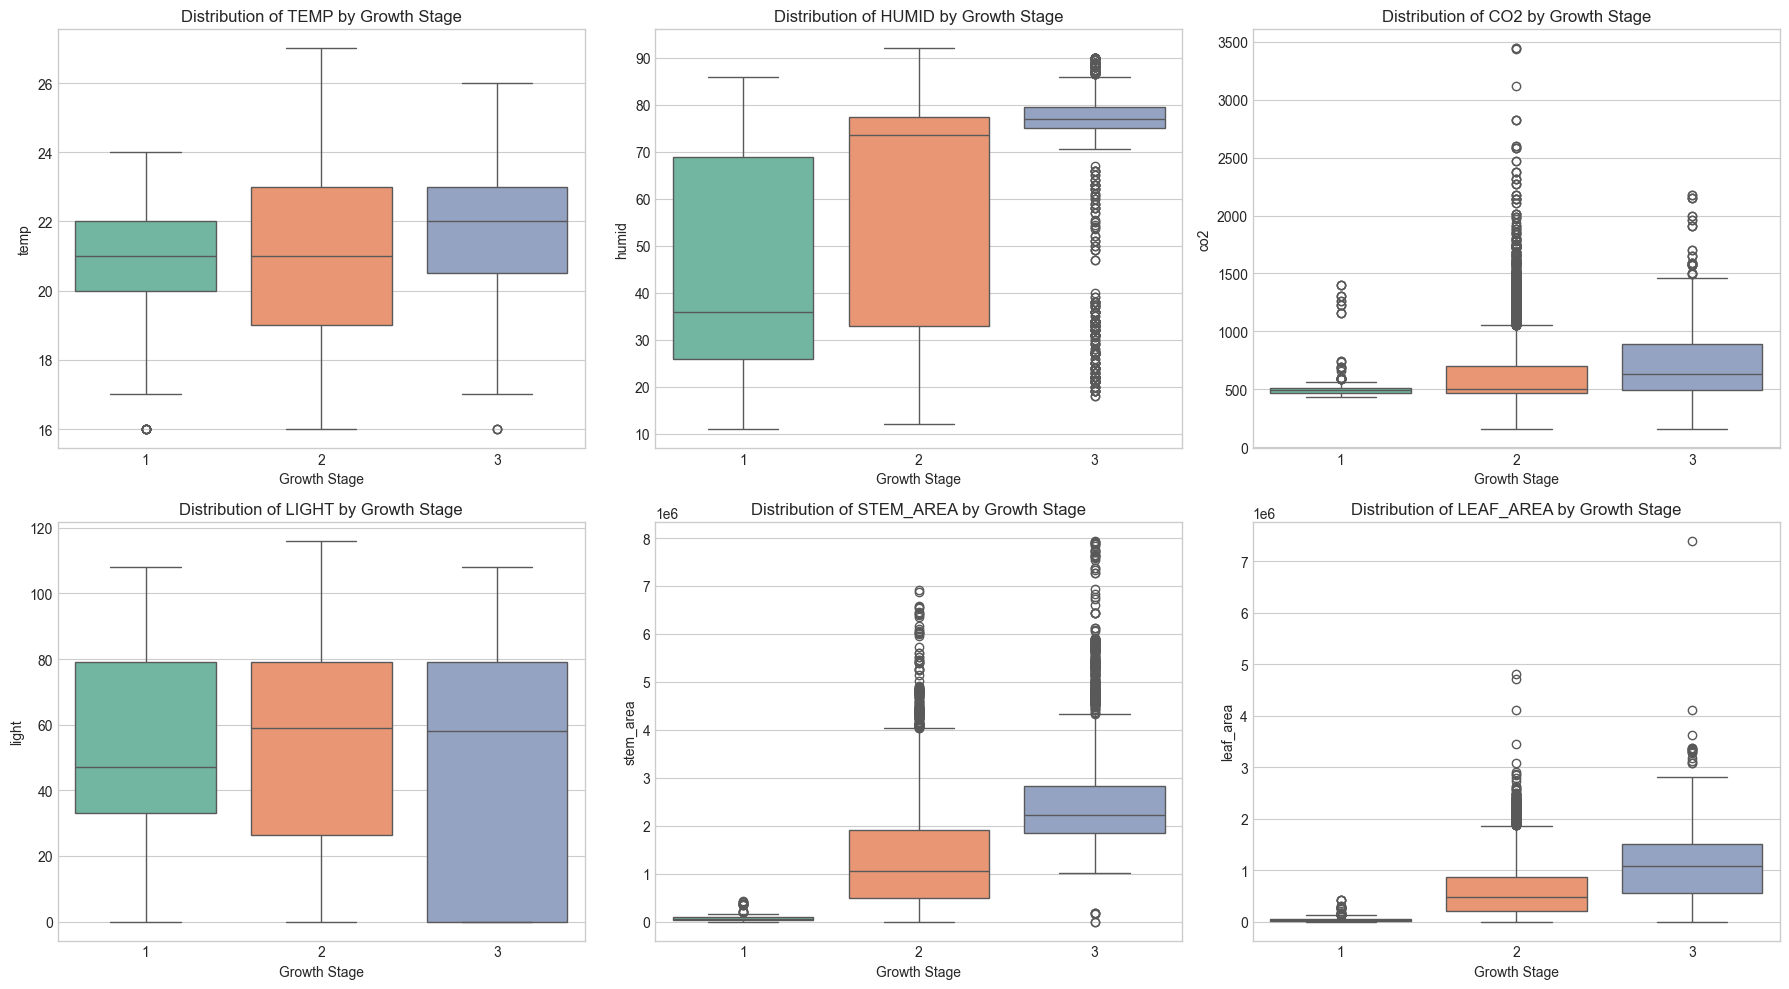

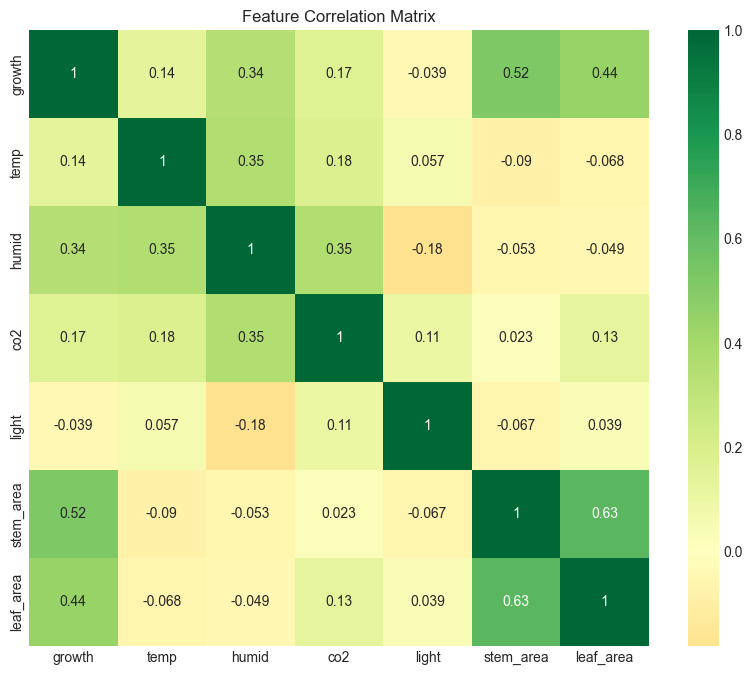

In [4]:
# Setting the style for a research paper feel
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# List of numeric columns we want to analyze against growth
features = ['temp', 'humid', 'co2', 'light', 'stem_area', 'leaf_area']

# Create a figure with a grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    # We use a boxplot to see the distribution per growth stage (1, 2, 3)
    sns.boxplot(x='growth', y=col, data=df, ax=axes[i], palette="Set2", hue='growth', legend=False)
    axes[i].set_title(f'Distribution of {col.upper()} by Growth Stage', fontsize=12)
    axes[i].set_xlabel('Growth Stage')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
# This helps check if Area and Environmental factors are actually linked
plt.figure(figsize=(10, 8))
correlation_matrix = df[['growth', 'temp', 'humid', 'co2', 'light', 'stem_area', 'leaf_area']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Feature Correlation Matrix")
plt.show()